# Phase transition validation

Produces Figure 1.

In [1]:
import sys
sys.path.insert(0, "..")   # make src importable from the repository root

from src.utils import load_results

results = load_results("phase_transition_validation")

In [2]:
import numpy as np
from src import theory
from src.figstyle import (DASHES, MARKERS, PALETTE, PT, figure, panel_label,
                          param_colors, save_figure, threshold_line,
                          use_manuscript_style)
from src.analysis import mean_crossing, threshold_from_levels

use_manuscript_style()
transition = results["transition"]
threshold_sweeps = results["threshold_sweeps"]
col = results["collapse"]
B_ALPHA = (col["alpha_x"], col["alpha_y"])
B_RHO_X = col["rho_x"]
B_RHO_Y = sorted(col["rho_y_values"])
LEVELS = (0.05, 0.10, 0.15)   # recovery levels averaged in the crossing statistic
HEIGHT_PT = 138.0


Wrote figures/fig1_phase_transition_validation.pdf
theta_c=1.3942  kappa=0.4615  retentions in (c): 18
hadamard transition crossing: 1.6194, 95% interval (1.6031190067902086, 1.6363785922975729)
qr transition crossing: 1.6259, 95% interval (1.6112549610399642, 1.6405911306695715)


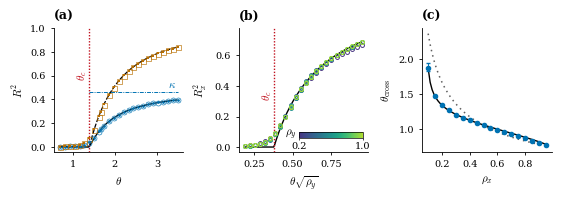

In [3]:
fig, (axa, axb, axc) = figure(HEIGHT_PT, 3)

ax = axa
p1 = transition['parameters']
theta = np.asarray(transition['theta'])
order = np.argsort(theta)
th = theta[order]
tc = transition['theta_c']
fine = np.linspace(theta.min(), theta.max(), 300)
curves = np.array([theory.overlaps_at(p1['alpha_x'], p1['alpha_y'], p1['rho_x'],
                                      p1['rho_y'], float(t)) for t in fine])
ax.plot(fine, curves[:, 0], color=PALETTE['theory'], lw=0.9,
        ls=DASHES['theory'], zorder=1)
ax.plot(fine, curves[:, 1], color=PALETTE['theory'], lw=0.9,
        ls=DASHES['theory_alt'], zorder=1)

for key, role in (('Rx2', 'x'), ('Ry2', 'y')):
    for kind, ms, mfc, mew, z in (('qr', 3.6, 'none', 0.45, 3),
                                  ('hadamard', 2.0, None, 0.0, 4)):
        rows = [r for r in transition['rows'] if r['design'] == kind]
        v = np.array([r[key] for r in rows]).mean(axis=0)[order]
        ax.plot(th, v, MARKERS[role], ms=ms, mfc=mfc, mew=mew, lw=0,
                color=PALETTE[role], zorder=z)

kappa = theory.kappa(p1['alpha_x'], p1['rho_x'])
ax.hlines(kappa, tc, th.max(), color=PALETTE['x'], lw=0.7,
          linestyles=[DASHES['ceiling']], zorder=1)
ax.annotate(r'$\kappa$', (th.max(), kappa), textcoords='offset points',
            xytext=(-1, 3), fontsize=PT['annot'], color=PALETTE['x'],
            ha='right', zorder=9)
threshold_line(ax, tc, r'$\theta_c$', y=0.62)
ax.set_xlabel(r'$\theta$')
ax.set_ylabel(r'$R^2$')
ax.set_ylim(-0.04, 1.0)
panel_label(ax, '(a)')

grid = np.asarray(col['scaled_grid'])
fineb = np.linspace(grid.min(), grid.max(), 300)
cols, sm = param_colors('rho_y', B_RHO_Y)
predb = np.array([theory.overlaps_at(*B_ALPHA, B_RHO_X, 1.0, float(s))[0]
                  for s in fineb])
axb.plot(fineb, predb, color=PALETTE['theory'], lw=1.0, ls=DASHES['theory'],
         zorder=2)
for i, (c, ry) in enumerate(zip(cols, B_RHO_Y)):
    axb.plot(grid, col['curves'][ry]['Rx2'].mean(axis=1), MARKERS['x'], ms=2.8,
             mfc='none', mec=c, mew=0.7, zorder=3 + i)
threshold_line(axb, col['scaled_theta_c'], r'$\theta_c$', y=0.46)
axb.set_xlabel(r'$\theta\sqrt{\rho_y}$')
axb.set_ylabel(r'$R_x^2$')
axb.set_ylim(-0.03, 0.78)
panel_label(axb, '(b)')

cax = axb.inset_axes([0.47, 0.11, 0.49, 0.05])
cb = fig.colorbar(sm, cax=cax, orientation='horizontal')
cb.set_ticks([min(B_RHO_Y), max(B_RHO_Y)])
cb.ax.tick_params(labelsize=PT['tick'], length=1.5, width=0.5, pad=1)
cb.outline.set_linewidth(0.5)
axb.text(0.45, 0.135, r'$\rho_y$', transform=axb.transAxes, ha='right',
         va='center', fontsize=PT['annot'])

ax = axc
sweep_keys = sorted(threshold_sweeps)
rho, meas, err = [], [], [[], []]
for key in sweep_keys:
    e = threshold_sweeps[key]
    g = np.asarray(e['theta'])
    est = threshold_from_levels(g, e['Rx2'], LEVELS)
    lo, hi = est['ci95']
    rho.append(e['rho_x'])
    meas.append(est['theta_hat'])
    err[0].append(est['theta_hat'] - lo)
    err[1].append(hi - est['theta_hat'])
o = np.argsort(rho)
rho, meas = np.asarray(rho)[o], np.asarray(meas)[o]

p0 = threshold_sweeps[sweep_keys[0]]

def crossing(rx, iso):
    g = np.linspace(0.3, 3.0, 400)
    if iso:
        c = [theory.isotropic_reference(p0['alpha_x'], p0['alpha_y'],
                                        rx * p0['rho_y'], float(t))[0]
             for t in g]
    else:
        c = [theory.overlaps_at(p0['alpha_x'], p0['alpha_y'], rx, p0['rho_y'],
                                float(t))[0] for t in g]
    return mean_crossing(g, c, LEVELS)[0]

dense = np.linspace(rho.min(), rho.max(), 60)
ax.plot(dense, [crossing(r, False) for r in dense], color=PALETTE['theory'],
        lw=1.0, ls=DASHES['theory'], zorder=3)
ax.plot(dense, [crossing(r, True) for r in dense], color=PALETTE['isotropic'],
        lw=1.1, ls=DASHES['isotropic'], zorder=2)
ax.errorbar(rho, meas, yerr=[np.asarray(err[0])[o], np.asarray(err[1])[o]],
            fmt=MARKERS['x'], ms=3.0, color=PALETTE['x'], mec=PALETTE['x'],
            elinewidth=0.7, capsize=1.4, lw=0, zorder=4)
ax.set_xlabel(r'$\rho_x$')
ax.set_ylabel(r'$\theta_{\mathrm{cross}}$')
ax.set_xticks([0.2, 0.4, 0.6, 0.8])
panel_label(ax, '(c)')

save_figure(fig, 'fig1_phase_transition_validation')
print(f'theta_c={tc:.4f}  kappa={kappa:.4f}  retentions in (c): {len(rho)}')
for design in ('hadamard', 'qr'):
    trial_curves = np.stack([row['Rx2'] for row in transition['rows']
                             if row['design'] == design])[:, order].T
    estimate = threshold_from_levels(th, trial_curves, (0.05, 0.10, 0.15, 0.20))
    print(f'{design} transition crossing: {estimate["theta_hat"]:.4f}, '
          f'95% interval {estimate["ci95"]}')
